#Lab6: Business Applications with Tabular Data

---

## Part 1: Classification

This data set contains information of cars purchased at the Auction.
<br>
We will use this file to predict the quality of buying decisions and visualize decision processes.
<br>
<br>
VARIABLE DESCRIPTIONS:<br>
Auction: Auction provider at which the  vehicle was purchased<br>
Color: Vehicle Color<br>
IsBadBuy: Identifies if the kicked vehicle was an avoidable purchase<br>
MMRCurrentAuctionAveragePrice: Acquisition price for this vehicle in average condition as of current day<br>
Size: The size category of the vehicle (Compact, SUV, etc.)<br>
TopThreeAmericanName:Identifies if the manufacturer is one of the top three American manufacturers<br>
VehBCost: Acquisition cost paid for the vehicle at time of purchase<br>
VehicleAge: The Years elapsed since the manufacturer's year<br>
VehOdo: The vehicles odometer reading<br>
WarrantyCost: Warranty price (term=36month  and millage=36K)<br>
WheelType: The vehicle wheel type description (Alloy, Covers)<br>
<br>
Target variable: **IsBadBuy**

###1. Upload and clean data

In [ ]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import classification_report

from sklearn import preprocessing
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from itertools import chain
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
# Read data
carAuction = pd.read_csv("/content/drive/MyDrive/DL_data/carAuction.csv")
carAuction

,Auction,Color,IsBadBuy,MMRCurrentAuctionAveragePrice,Size,TopThreeAmericanName,VehBCost,VehicleAge,VehOdo,WarrantyCost,WheelType
0,ADESA,WHITE,No,2871,LARGE TRUCK,FORD,5300,8,75419,869,Alloy
1,ADESA,GOLD,Yes,1840,VAN,FORD,3600,8,82944,2322,Alloy
2,ADESA,RED,No,8931,SMALL SUV,CHRYSLER,7500,4,57338,588,Alloy
3,ADESA,GOLD,No,8320,CROSSOVER,FORD,8500,5,55909,1169,Alloy
4,ADESA,GREY,No,11520,LARGE TRUCK,FORD,10100,5,86702,853,Alloy
...,...,...,...,...,...,...,...,...,...,...,...
9995,ADESA,RED,No,7536,SMALL SUV,CHRYSLER,6600,4,85377,983,Alloy
9996,ADESA,BLACK,No,4921,LARGE TRUCK,GM,7000,7,89665,1543,Alloy
9997,ADESA,BLACK,No,9263,MEDIUM SUV,CHRYSLER,9000,4,59383,1417,Alloy
9998,ADESA,BLUE,No,3240,MEDIUM,OTHER,5500,4,48642,482,Covers


In [ ]:
# Show the head rows of a data frame
carAuction.head()

,Auction,Color,IsBadBuy,MMRCurrentAuctionAveragePrice,Size,TopThreeAmericanName,VehBCost,VehicleAge,VehOdo,WarrantyCost,WheelType
0,ADESA,WHITE,No,2871,LARGE TRUCK,FORD,5300,8,75419,869,Alloy
1,ADESA,GOLD,Yes,1840,VAN,FORD,3600,8,82944,2322,Alloy
2,ADESA,RED,No,8931,SMALL SUV,CHRYSLER,7500,4,57338,588,Alloy
3,ADESA,GOLD,No,8320,CROSSOVER,FORD,8500,5,55909,1169,Alloy
4,ADESA,GREY,No,11520,LARGE TRUCK,FORD,10100,5,86702,853,Alloy


In [ ]:
# Examine variable type
carAuction.dtypes

Auction                          object
Color                            object
IsBadBuy                         object
MMRCurrentAuctionAveragePrice     int64
Size                             object
TopThreeAmericanName             object
VehBCost                          int64
VehicleAge                        int64
VehOdo                            int64
WarrantyCost                      int64
WheelType                        object
dtype: object

In [ ]:
# Change categorical variables to "category"
carAuction['Auction'] = carAuction['Auction'].astype('category')
carAuction['Color'] = carAuction['Color'].astype('category')
carAuction['IsBadBuy'] = carAuction['IsBadBuy'].astype('category')
carAuction['Size'] = carAuction['Size'].astype('category')
carAuction['TopThreeAmericanName'] = carAuction['TopThreeAmericanName'].astype('category')
carAuction['WheelType'] = carAuction['WheelType'].astype('category')

In [ ]:
# Examine variable type
carAuction.dtypes

Auction                          category
Color                            category
IsBadBuy                         category
MMRCurrentAuctionAveragePrice       int64
Size                             category
TopThreeAmericanName             category
VehBCost                            int64
VehicleAge                          int64
VehOdo                              int64
WarrantyCost                        int64
WheelType                        category
dtype: object

###2. Partition the data set for Decision Tree model

In [ ]:
# Create dummy variables
carAuction = pd.get_dummies(carAuction, columns=['Auction','Color','Size','TopThreeAmericanName','WheelType'],drop_first=True)
carAuction

,IsBadBuy,MMRCurrentAuctionAveragePrice,VehBCost,VehicleAge,VehOdo,WarrantyCost,Auction_MANHEIM,Auction_OTHER,Color_BLACK,Color_BLUE,...,Size_SMALL TRUCK,Size_SPECIALTY,Size_SPORTS,Size_VAN,TopThreeAmericanName_FORD,TopThreeAmericanName_GM,TopThreeAmericanName_OTHER,WheelType_Covers,WheelType_Special,WheelType_unkwnWheel
0,No,2871,5300,8,75419,869,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,Yes,1840,3600,8,82944,2322,0,0,0,0,...,0,0,0,1,1,0,0,0,0,0
2,No,8931,7500,4,57338,588,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,No,8320,8500,5,55909,1169,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,No,11520,10100,5,86702,853,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,No,7536,6600,4,85377,983,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9996,No,4921,7000,7,89665,1543,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
9997,No,9263,9000,4,59383,1417,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
9998,No,3240,5500,4,48642,482,0,0,0,1,...,0,0,0,0,0,0,1,1,0,0


In [ ]:
# Apply standardization
numeric_variables = carAuction[['MMRCurrentAuctionAveragePrice', 'VehBCost', 'VehicleAge', 'VehOdo', 'WarrantyCost']]
scaler_s = StandardScaler().fit(numeric_variables)
standard_variables = scaler_s.transform(numeric_variables)
print(standard_variables)
carAuction[['MMRCurrentAuctionAveragePrice', 'VehBCost', 'VehicleAge', 'VehOdo', 'WarrantyCost']] = standard_variables
carAuction

[[-1.33756114 -0.80983074  2.22646285  0.26402682 -0.67480576]
 [-1.7625022  -1.77920496  2.22646285  0.77636434  1.71108844]
 [ 1.16015257  0.44465355 -0.1066831  -0.96701301 -1.13622094]
 ...
 [ 1.29699102  1.29998375 -0.1066831  -0.82777976  0.22503596]
 [-1.18547263 -0.69578671 -0.1066831  -1.55907774 -1.31027792]
 [ 0.01310022  0.15954349  0.47660339  0.75042406 -0.0606802 ]]


,IsBadBuy,MMRCurrentAuctionAveragePrice,VehBCost,VehicleAge,VehOdo,WarrantyCost,Auction_MANHEIM,Auction_OTHER,Color_BLACK,Color_BLUE,...,Size_SMALL TRUCK,Size_SPECIALTY,Size_SPORTS,Size_VAN,TopThreeAmericanName_FORD,TopThreeAmericanName_GM,TopThreeAmericanName_OTHER,WheelType_Covers,WheelType_Special,WheelType_unkwnWheel
0,No,-1.337561,-0.809831,2.226463,0.264027,-0.674806,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,Yes,-1.762502,-1.779205,2.226463,0.776364,1.711088,0,0,0,0,...,0,0,0,1,1,0,0,0,0,0
2,No,1.160153,0.444654,-0.106683,-0.967013,-1.136221,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,No,0.908320,1.014874,0.476603,-1.064306,-0.182192,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,No,2.227245,1.927226,0.476603,1.032227,-0.701079,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,No,0.585184,-0.068545,-0.106683,0.942014,-0.487612,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9996,No,-0.492625,0.159543,1.643176,1.233962,0.431934,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
9997,No,1.296991,1.299984,-0.106683,-0.827780,0.225036,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
9998,No,-1.185473,-0.695787,-0.106683,-1.559078,-1.310278,0,0,0,1,...,0,0,0,0,0,0,1,1,0,0


In [ ]:
# Partition the data
target = carAuction['IsBadBuy']
predictors = carAuction.drop(['IsBadBuy'], axis=1)
predictors_train, predictors_test, target_train, target_test = train_test_split(predictors, target, test_size = 0.3, random_state = 0)
print(predictors_train.shape, predictors_test.shape, target_train.shape, target_test.shape)

(7000, 39) (3000, 39) (7000,) (3000,)


In [ ]:
# Examine the porportion of target variable for training data set
print(target_train.value_counts(normalize= True))

No     0.869571
Yes    0.130429
Name: IsBadBuy, dtype: float64


In [ ]:
# Examine the porportion of target variable for testing data set
print(target_test.value_counts(normalize= True))

No     0.872667
Yes    0.127333
Name: IsBadBuy, dtype: float64


### 3. Neural network prediction and evaluation

In [ ]:
# Build a neural network on training data
class neural_network(nn.Module):
    def __init__(self,  in_size, hidden_size, out_size):
        super().__init__()
        self.network = nn.Sequential(
          nn.Linear(in_size, hidden_size),
          nn.ReLU(),
          nn.Linear(hidden_size, hidden_size),
          nn.ReLU(),
          nn.Linear(hidden_size, out_size))

    def forward(self, x):
        out = self.network(x)
        return out

In [ ]:
# Encode label to numeric
label_encoder = preprocessing.LabelEncoder()
new_label = label_encoder.fit_transform(target_train)
new_label[:5], target_train[:5]

(array([0, 0, 0, 1, 0]), 7681     No
 9031     No
 3691     No
 202     Yes
 5625     No
 Name: IsBadBuy, dtype: category
 Categories (2, object): ['No', 'Yes'])

In [ ]:
# Create tensors from pandas dataframe
predictors_train_tensor = torch.tensor(predictors_train.values)
target_train_tensor = torch.tensor(label_encoder.transform(target_train.values))
predictors_test_tensor = torch.tensor(predictors_test.values)
target_test_tensor = torch.tensor(label_encoder.transform(target_test.values))

# Create tensor dataset (set target variable to long int type)
train_dataset = torch.utils.data.TensorDataset(predictors_train_tensor.float(), target_train_tensor.long())
test_dataset = torch.utils.data.TensorDataset(predictors_test_tensor.float(), target_test_tensor.long())

# Define training and testing data loader, and set batch size to 64
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
# Define training loop function
def training_loop(n_epochs, optimizer, model, loss_fn, train_loader):
    for epoch in range(0, n_epochs):
        # Training Phase 
        model.train()
        loss_train = 0.0
        for inputs, labels in train_loader:

            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_train += loss.item()

        if epoch == 0 or epoch == n_epochs-1 or epoch % 10 == 0:
            print('Epoch {}, Training loss {}'.format(epoch, loss_train / len(train_loader)))

In [ ]:
# Model training
torch.manual_seed(0)
model = neural_network(39, 64, 2)
optimizer = optim.Adam(model.parameters())
loss_fn = nn.CrossEntropyLoss()

training_loop(n_epochs = 50, optimizer = optimizer, model = model, loss_fn = loss_fn, train_loader = train_loader)

Epoch 0, Training loss 0.41379300112074074
Epoch 10, Training loss 0.29682058522647076
Epoch 20, Training loss 0.27115713127634744
Epoch 30, Training loss 0.24331858537413859
Epoch 40, Training loss 0.21893687932328745
Epoch 49, Training loss 0.1982664566148411


In [ ]:
# Define testing function
def test(model, train_loader, test_loader):
 
  # testing phase
  model.eval()
  predict_train = []
  predict_test = []
  labels_train = []
  labels_test = []

  with torch.no_grad():
      for inputs, labels in train_loader:
          outputs = model(inputs)
          index_, predicted = torch.max(outputs, dim=1)
          predict_train.append(predicted.tolist())
          labels_train.append(labels.tolist())

      for inputs, labels in test_loader:
          outputs = model(inputs)
          index_, predicted = torch.max(outputs, dim=1)
          predict_test.append(predicted.tolist())
          labels_test.append(labels.tolist())

  print("Confusion matrix on train:\n",  confusion_matrix(list(chain(*labels_train)), list(chain(*predict_train)), labels=[0, 1]))
  print()
  print("Classification report on train:\n",  classification_report(list(chain(*labels_train)), list(chain(*predict_train)), labels=[0, 1]))
  print()
  print("Confusion matrix on test:\n",  confusion_matrix(list(chain(*labels_test)), list(chain(*predict_test)), labels=[0, 1]))
  print()
  print("Classification report on test:\n",  classification_report(list(chain(*labels_test)), list(chain(*predict_test)), labels=[0, 1]))


In [ ]:
# Examine evaluation results
test(model, train_loader, test_loader)

Confusion matrix on train:
 [[6062   25]
 [ 471  442]]

Classification report on train:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96      6087
           1       0.95      0.48      0.64       913

    accuracy                           0.93      7000
   macro avg       0.94      0.74      0.80      7000
weighted avg       0.93      0.93      0.92      7000


Confusion matrix on test:
 [[2547   71]
 [ 284   98]]

Classification report on test:
               precision    recall  f1-score   support

           0       0.90      0.97      0.93      2618
           1       0.58      0.26      0.36       382

    accuracy                           0.88      3000
   macro avg       0.74      0.61      0.65      3000
weighted avg       0.86      0.88      0.86      3000



Q1. On the testing set, how many bad buy cars are predicted as Not bad buy?<br>
284

Q2. Does the decision tree model have better performance on majority (IsBadBuy = 'No') or minority class (IsBadBuy = 'Yes')? why? <br>
The model has better performance on majority class. It has much higher F-measure value (as well as higher precision and recall values) on majority class.


Q3. Assume the following costs/benefits: 
*   Cost of buying a bad car: \$2500
*   Profit of purchasing a good car: \$350
*   Opportunity cost of a good car that is missed: \$350
<br>
Based on the above costs / benefits, what is the total net benefit / cost of this neural network on testing data?<br>
<br>
Cost: 284 * 2500<br>
Profit: 2547 * 350<br>
Opportunity cost: 71 * 350<br>
Profit – Cost - Opportunity cost: 156,600<br>
<br>


## Part 2: Numeric Prediction

---

In order for a health insurance company to make money, it needs to collect more
in yearly premiums than it spends on medical care to its beneficiaries. As a result, insurers invest a great deal of time and money in developing models that accurately forecast medical expenses for the insured population.<br>
<br>
Medical expenses are difficult to estimate because the most costly conditions are rare and seemingly random. Still, some conditions are more prevalent for certain segments of the population. For instance, lung cancer is more likely among smokers than non-smokers, and heart disease may be more likely among the obese.<br>
<br>
The goal of this analysis is to use patient data to estimate the average medical
care expenses for such population segments. These estimates can be used to create actuarial tables that set the price of yearly premiums higher or lower, 
depending on the expected treatment costs.<br>
<br>
The insurance data set has 1338 observations of 7 variables.
<br>
We will use this file to predict the medical expenses.
<br>
<br>
VARIABLE DESCRIPTIONS:<br>
age:	      age in years<br>
sex:	      gender<br>
bmi:	      body mass index<br>
children:	how many children do they have?<br>
smoker:	  do they smoke?<br>
region:	  geographic region<br>
expenses:	yearly medical expenses<br>
<br>
Target variable: **expenses**

### Upload and clean data

In [ ]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import libraries
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [ ]:
# Read data
insurance = pd.read_csv("/content/drive/MyDrive/DL_data/insurance.csv")
insurance

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95


In [ ]:
# Show the head rows of a data frame
insurance.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [ ]:
# Examine variable type
insurance.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
expenses    float64
dtype: object

In [ ]:
# Change categorical variables to "category"
insurance['sex'] = insurance['sex'].astype('category')
insurance['smoker'] = insurance['smoker'].astype('category')
insurance['region'] = insurance['region'].astype('category')

In [ ]:
# Examine variable type
insurance.dtypes

age            int64
sex         category
bmi          float64
children       int64
smoker      category
region      category
expenses     float64
dtype: object

Text(0.5, 1.0, 'Histogram of expenses in the insurance data set')

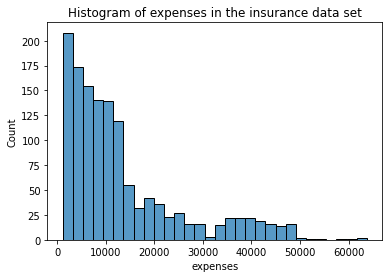

In [ ]:
# Data exploration: some examples
# Histogram of insurance expenses
snsplot = sns.histplot(x='expenses', data = insurance)
snsplot.set_title("Histogram of expenses in the insurance data set")

In [ ]:
# exploring relationships among all numeric variables: correlation matrix
insurance.corr()

,age,bmi,children,expenses
age,1.000000,0.109341,0.042469,0.299008
bmi,0.109341,1.000000,0.012645,0.198576
children,0.042469,0.012645,1.000000,0.067998
expenses,0.299008,0.198576,0.067998,1.000000


### Partition the data set for regression model

In [ ]:
# Create dummy variables
insurance = pd.get_dummies(insurance, columns=['sex','smoker','region'], drop_first=True)
insurance

,age,bmi,children,expenses,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.9,0,16884.92,0,1,0,0,1
1,18,33.8,1,1725.55,1,0,0,1,0
2,28,33.0,3,4449.46,1,0,0,1,0
3,33,22.7,0,21984.47,1,0,1,0,0
4,32,28.9,0,3866.86,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,31.0,3,10600.55,1,0,1,0,0
1334,18,31.9,0,2205.98,0,0,0,0,0
1335,18,36.9,0,1629.83,0,0,0,1,0
1336,21,25.8,0,2007.95,0,0,0,0,1


In [ ]:
# Apply standardization
numeric_variables = insurance[['age', 'bmi', 'children']]
scaler_s = StandardScaler().fit(numeric_variables)
standard_variables = scaler_s.transform(numeric_variables)
print(standard_variables)
insurance[['age', 'bmi', 'children']] = standard_variables

[[-1.43876426 -0.4536457  -0.90861367]
 [-1.50996545  0.51418574 -0.07876719]
 [-0.79795355  0.38295436  1.58092576]
 ...
 [-1.50996545  1.02270734 -0.90861367]
 [-1.29636188 -0.79812808 -0.90861367]
 [ 1.55168573 -0.25679863 -0.90861367]]


In [ ]:
# Partition the data
target = insurance['expenses']
predictors = insurance.drop(['expenses'],axis=1)
predictors_train, predictors_test, target_train, target_test = train_test_split(predictors, target, test_size=0.3, random_state=0)
print(predictors_train.shape, predictors_test.shape, target_train.shape, target_test.shape)

(936, 8) (402, 8) (936,) (402,)


Text(0.5, 1.0, 'Histogram of expenses in the training data set')

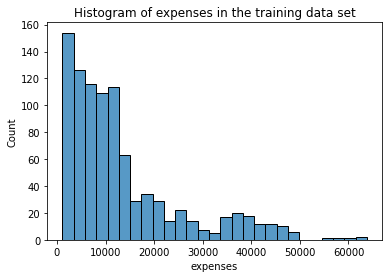

In [ ]:
# Examine the distribution of target variable for training data set
snsplot = sns.histplot(data = target_train)
snsplot.set_title("Histogram of expenses in the training data set")

Text(0.5, 1.0, 'Histogram of expenses in the testing data set')

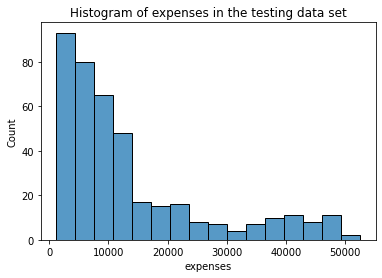

In [ ]:
# Examine the distribution of target variable for testing data set
snsplot = sns.histplot(data = target_test)
snsplot.set_title("Histogram of expenses in the testing data set")

### 3. Neural network prediction and evaluation

In [ ]:
# Build a neural network on training data
class neural_network(nn.Module):
    def __init__(self,  in_size, hidden_size, out_size):
        super().__init__()
        self.network = nn.Sequential(
          nn.Linear(in_size, hidden_size),
          nn.ReLU(),
          nn.Linear(hidden_size, hidden_size),
          nn.ReLU(),
          nn.Linear(hidden_size, out_size))

    def forward(self, x):
        out = self.network(x)
        return out.squeeze()

In [ ]:
# Create tensor from pandas dataframe
predictors_train_tensor = torch.tensor(predictors_train.values)
target_train_tensor = torch.tensor(target_train.values)
predictors_test_tensor = torch.tensor(predictors_test.values)
target_test_tensor = torch.tensor(target_test.values)

# Create tensor dataset (set target variable to float type)
train_dataset = torch.utils.data.TensorDataset(predictors_train_tensor.float(), target_train_tensor.float())
test_dataset = torch.utils.data.TensorDataset(predictors_test_tensor.float(), target_test_tensor.float())

# Define training and testing data loader, and set batch size to 64
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
# Define training loop function
def training_loop(n_epochs, optimizer, model, loss_fn, train_loader):
    for epoch in range(0, n_epochs):
        # Training Phase 
        model.train()
        loss_train = 0.0
        for inputs, labels in train_loader:

            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_train += loss.item()

        if epoch == 0 or epoch == n_epochs-1 or epoch % 100 == 0:
            print('Epoch {}, Training loss {}'.format(epoch, loss_train / len(train_loader)))

In [ ]:
# Model training
torch.manual_seed(0)
model = neural_network(8, 128, 1)
optimizer = optim.Adam(model.parameters(), lr = 0.1)
loss_fn = nn.MSELoss()

training_loop(n_epochs = 500, optimizer = optimizer, model = model, loss_fn = loss_fn, train_loader = train_loader)

Epoch 0, Training loss 199992728.53333333
Epoch 100, Training loss 22035437.366666667
Epoch 200, Training loss 15782689.9
Epoch 300, Training loss 9938172.3
Epoch 400, Training loss 6737472.733333333
Epoch 499, Training loss 4719505.883333334


In [ ]:
# Define testing function
def test(model, train_loader, test_loader):
 
  # testing phase
  model.eval()
  predict_train = []
  predict_test = []
  label_train = []
  label_test = []

  with torch.no_grad():
      for inputs, labels in train_loader:
          outputs = model(inputs)
          predict_train.append(outputs.tolist())
          label_train.append(labels.tolist())

      for inputs, labels in test_loader:
          outputs = model(inputs)
          predict_test.append(outputs.tolist())
          label_test.append(labels.tolist())
  
  MAE_train = mean_absolute_error(list(chain(*label_train)), list(chain(*predict_train)))
  RMSE_train = mean_squared_error(list(chain(*label_train)), list(chain(*predict_train)), squared=False)

  MAE_test = mean_absolute_error(list(chain(*label_test)), list(chain(*predict_test)))
  RMSE_test = mean_squared_error(list(chain(*label_test)), list(chain(*predict_test)), squared=False)

  print("Training MAE and RMSE:", MAE_train, RMSE_train)
  print()
  print("testing MAE and RMSE:", MAE_test, RMSE_test)

In [ ]:
# Examine evaluation results
test(model, train_loader, test_loader)

Training MAE and RMSE: 981.2650252774231 1850.7609150237186

testing MAE and RMSE: 3531.99352389663 6494.012998850611


In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/DL_lab/Lab6_Business_Applications_with_Tabular_Data_Solution.ipynb"